In [ ]:
import os
os.chdir("..")


In [1]:
import cv2
from PIL import Image
import glob
import numpy as np
from matplotlib import pyplot as plt
from patchify import patchify, unpatchify
import scipy
import scipy.io as sio 
from scipy.io import readsav
import os, sys
import imutils
import pandas as pd
import math
from array import array

In [2]:
from tensorflow.keras.models import load_model
model = load_model("/home/dibya/ML_project/plage_suncharts_manual_pole3.h5",compile=False)

2025-10-04 14:44:27.924136: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-04 14:44:27.927001: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-04 14:44:27.935786: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759569267.957586  912864 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759569267.963335  912864 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759569267.977725  912864 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [3]:
directory = "/home/dibya/ML_project/prediction_patch/"
#directory = "/home/dibya/ML_project/maxima_activity_img/"
#directory = "/home/dibya/ML_project/middle_activity_img/"
#directory = "/home/dibya/ML_project/minimum_activity_img/"

name_image =[]
for root, _, files in os.walk(directory):
        for filename in files:
            if filename.endswith('sch_19370102_0849_kkkk.tif'):#sch_19750223_0000_xmmm.tif,sch_19370102_0849_kkkk.tif
                name_image.append(filename)
                name_image.sort()
print(name_image)

['sch_19370102_0849_kkkk.tif']


In [4]:
directory_sh = "/home/dibya/ML_project/prediction_patch/"
#directory = "/home/dibya/ML_project/maxima_activity_img/"
#directory = "/home/dibya/ML_project/middle_activity_img/"
#directory = "/home/dibya/ML_project/minimum_activity_img/"

name_image_sh =[]
for root, _, files in os.walk(directory_sh):
        for filename in files:
            if filename.endswith('sch_19370102_0849_kkkk_sharpen.tif'):#sch_19750223_0000_xmmm.tif,sch_19370102_0849_kkkk.tif
                name_image_sh.append(filename)
                name_image_sh.sort()
print(name_image_sh)

['sch_19370102_0849_kkkk_sharpen.tif']


In [5]:
directory1 = "/home/dibya/ML_project/prediction_patch1/"

name_image1 =[]
for root, _, files in os.walk(directory1):
        for filename in files:
            if filename.endswith('sch_19750223_0000_xmmm.tif'):#sch_19750223_0000_xmmm.tif,sch_19370102_0849_kkkk.tif
                name_image1.append(filename)
                name_image1.sort()
print(name_image1)

['sch_19750223_0000_xmmm.tif']


In [6]:
directory1_sh = "/home/dibya/ML_project/prediction_patch1/"

name_image1_sh =[]
for root, _, files in os.walk(directory1_sh):
        for filename in files:
            if filename.endswith('sch_19750223_0000_xmmm_sharpen.tif'):#sch_19750223_0000_xmmm.tif,sch_19370102_0849_kkkk.tif
                name_image1_sh.append(filename)
                name_image1_sh.sort()
print(name_image1_sh)

['sch_19750223_0000_xmmm_sharpen.tif']


In [7]:
file_path = "/home/dibya/ML_project/disk_center_v2.txt"  # Replace with the actual path to your text file

x =[]
y=[]
ra=[]
angle =[]

with open(file_path, "r") as file:
    lines = file.readlines()[9821:9822] # 23558: 23559,  9821,9822
    
    # Create a list to store the data
    data = []
        
    # Iterate through the lines and split them by whitespace
    for line in lines:
        line_data = line.strip().split()
        data.append(line_data)
        
    # Create a pandas DataFrame
    df = pd.DataFrame(data,columns=['file_name','xcen','ycen','rad','ang'])
    
    xcen = df['xcen'].astype('float')
    ycen = df['ycen'].astype('float')
    rad = df['rad'].astype('float')
    ang = df['ang'].astype('float')
    
    
    
    # if df['file_name'] == name_image :
    #     pass
    # Match the file name with the 'file_name' column
    matching_rows = df['file_name'] == name_image
    # Check if there are any matching rows
    if not matching_rows.empty:
      print("File name matched!")
    # Process the matching rows here
    else:
      print("File name not found.")
    x.append(round(xcen[0:]))
    y.append(round(ycen[0:]))
    ra.append(round(rad[0:]))
    angle.append(round(ang[0:],2))
   
    
    shape = np.shape(df)
    #print(x)

x = np.reshape(x,(shape[0],1))
y = np.reshape(y,(shape[0],1))
ra = np.reshape(ra,(shape[0],1))
angle = np.reshape(angle,(shape[0],1))


x = [int(element) for element in x]
y = [int(element) for element in y]
ra = [int(element) for element in ra]
angle = [float(element) for element in angle]



print(x)
print(y)
print(ra)
print(angle)

File name matched!
[3096]
[3096]
[2400]
[0.0]


/tmp/ipykernel_912864/4265898719.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x = [int(element) for element in x]
/tmp/ipykernel_912864/4265898719.py:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = [int(element) for element in y]
/tmp/ipykernel_912864/4265898719.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ra = [int(element) for element in ra]
/tmp/ipykernel_912864/4265898719.py:57: DeprecationWarning: Conversion of an array with ndim > 0 to a

In [8]:
file_path = "/home/dibya/ML_project/disk_center_v2.txt"  # Replace with the actual path to your text file

x_sh =[]
y_sh=[]
ra_sh=[]
angle_sh =[]

with open(file_path, "r") as file:
    lines = file.readlines()[9821:9822] # 23558: 23559,  9821,9822
    
    # Create a list to store the data
    data = []
        
    # Iterate through the lines and split them by whitespace
    for line in lines:
        line_data = line.strip().split()
        data.append(line_data)
        
    # Create a pandas DataFrame
    df = pd.DataFrame(data,columns=['file_name','xcen','ycen','rad','ang'])
    
    xcen = df['xcen'].astype('float')
    ycen = df['ycen'].astype('float')
    rad = df['rad'].astype('float')
    ang = df['ang'].astype('float')
    
    
    
    # if df['file_name'] == name_image :
    #     pass
    # Match the file name with the 'file_name' column
    matching_rows = df['file_name'] == name_image
    # Check if there are any matching rows
    if not matching_rows.empty:
      print("File name matched!")
    # Process the matching rows here
    else:
      print("File name not found.")
    x_sh.append(round(xcen[0:]))
    y_sh.append(round(ycen[0:]))
    ra_sh.append(round(rad[0:]))
    angle_sh.append(round(ang[0:],2))
   
    
    shape = np.shape(df)
    #print(x)

x_sh = np.reshape(x_sh,(shape[0],1))
y_sh = np.reshape(y_sh,(shape[0],1))
ra_sh = np.reshape(ra_sh,(shape[0],1))
angle_sh = np.reshape(angle_sh,(shape[0],1))


x_sh = [int(element) for element in x_sh]
y_sh = [int(element) for element in y_sh]
ra_sh = [int(element) for element in ra_sh]
angle_sh = [float(element) for element in angle_sh]



print(x_sh)
print(y_sh)
print(ra_sh)
print(angle_sh)

File name matched!
[3096]
[3096]
[2400]
[0.0]


/tmp/ipykernel_912864/2981552423.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_sh = [int(element) for element in x_sh]
/tmp/ipykernel_912864/2981552423.py:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_sh = [int(element) for element in y_sh]
/tmp/ipykernel_912864/2981552423.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ra_sh = [int(element) for element in ra_sh]
/tmp/ipykernel_912864/2981552423.py:57: DeprecationWarning: Conversion of an array 

In [9]:
file_path = "/home/dibya/ML_project/disk_center_v2.txt"  # Replace with the actual path to your text file

x1 =[]
y1=[]
ra1=[]
angle1 =[]

with open(file_path, "r") as file:
    lines1 = file.readlines()[23558:23559] # 23558: 23559,  9821,9822
    
    # Create a list to store the data
    data1 = []
        
    # Iterate through the lines and split them by whitespace
    for line in lines1:
        line_data = line.strip().split()
        data1.append(line_data)
        
    # Create a pandas DataFrame
    df1 = pd.DataFrame(data1,columns=['file_name','xcen','ycen','rad','ang'])
    
    xcen1 = df1['xcen'].astype('float')
    ycen1 = df1['ycen'].astype('float')
    rad1 = df1['rad'].astype('float')
    ang1 = df1['ang'].astype('float')
    
    
    
    # if df['file_name'] == name_image :
    #     pass
    # Match the file name with the 'file_name' column
    matching_rows1 = df1['file_name'] == name_image1
    # Check if there are any matching rows
    if not matching_rows1.empty:
      print("File name matched!")
    # Process the matching rows here
    else:
      print("File name not found.")
    x1.append(round(xcen1[0:]))
    y1.append(round(ycen1[0:]))
    ra1.append(round(rad1[0:]))
    angle1.append(round(ang1[0:],2))
   
    
    shape1 = np.shape(df1)
    #print(x)

x1 = np.reshape(x1,(shape1[0],1))
y1 = np.reshape(y1,(shape1[0],1))
ra1 = np.reshape(ra1,(shape1[0],1))
angle1 = np.reshape(angle1,(shape1[0],1))


x1 = [int(element) for element in x1]
y1 = [int(element) for element in y1]
ra1 = [int(element) for element in ra1]
angle1 = [float(element) for element in angle1]



print(x1)
print(y1)
print(ra1)
print(angle1)

File name matched!
[3024]
[2832]
[2400]
[0.0]


/tmp/ipykernel_912864/3353435503.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x1 = [int(element) for element in x1]
/tmp/ipykernel_912864/3353435503.py:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y1 = [int(element) for element in y1]
/tmp/ipykernel_912864/3353435503.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ra1 = [int(element) for element in ra1]
/tmp/ipykernel_912864/3353435503.py:57: DeprecationWarning: Conversion of an array with ndim > 

In [10]:
file_path = "/home/dibya/ML_project/disk_center_v2.txt"  # Replace with the actual path to your text file

x1_sh =[]
y1_sh=[]
ra1_sh=[]
angle1_sh =[]

with open(file_path, "r") as file:
    lines1 = file.readlines()[23558:23559] # 23558: 23559,  9821,9822
    
    # Create a list to store the data
    data1 = []
        
    # Iterate through the lines and split them by whitespace
    for line in lines1:
        line_data = line.strip().split()
        data1.append(line_data)
        
    # Create a pandas DataFrame
    df1 = pd.DataFrame(data1,columns=['file_name','xcen','ycen','rad','ang'])
    
    xcen1 = df1['xcen'].astype('float')
    ycen1 = df1['ycen'].astype('float')
    rad1 = df1['rad'].astype('float')
    ang1 = df1['ang'].astype('float')
    
    
    
    # if df['file_name'] == name_image :
    #     pass
    # Match the file name with the 'file_name' column
    matching_rows1 = df1['file_name'] == name_image1
    # Check if there are any matching rows
    if not matching_rows1.empty:
      print("File name matched!")
    # Process the matching rows here
    else:
      print("File name not found.")
    x1_sh.append(round(xcen1[0:]))
    y1_sh.append(round(ycen1[0:]))
    ra1_sh.append(round(rad1[0:]))
    angle1_sh.append(round(ang1[0:],2))
   
    
    shape1 = np.shape(df1)
    #print(x)

x1_sh = np.reshape(x1_sh,(shape1[0],1))
y1_sh = np.reshape(y1_sh,(shape1[0],1))
ra1_sh = np.reshape(ra1_sh,(shape1[0],1))
angle1_sh = np.reshape(angle1_sh,(shape1[0],1))


x1_sh = [int(element) for element in x1_sh]
y1_sh = [int(element) for element in y1_sh]
ra1_sh = [int(element) for element in ra1_sh]
angle1_sh = [float(element) for element in angle1_sh]



print(x1_sh)
print(y1_sh)
print(ra1_sh)
print(angle1_sh)

File name matched!
[3024]
[2832]
[2400]
[0.0]


/tmp/ipykernel_912864/365254470.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x1_sh = [int(element) for element in x1_sh]
/tmp/ipykernel_912864/365254470.py:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y1_sh = [int(element) for element in y1_sh]
/tmp/ipykernel_912864/365254470.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ra1_sh = [int(element) for element in ra1_sh]
/tmp/ipykernel_912864/365254470.py:57: DeprecationWarning: Conversion of an arra

In [11]:
import random
image_dataset = []


x0_main = []
y0_main = []
rad_main = []


image_directory = "/home/dibya/ML_project/prediction_patch/"
#image_directory = "/home/dibya/ML_project/maxima_activity_img/"
#image_directory = "/home/dibya/ML_project/middle_activity_img/"
#image_directory = "/home/dibya/ML_project/minimum_activity_img/"


tif_files = [os.path.join(root, filename) for root, _, files in os.walk(image_directory) for filename in files if filename.endswith('sch_19370102_0849_kkkk.tif')]
tif_files.sort()

for k,image_path in enumerate(tif_files):
                filename = os.path.splitext(os.path.basename(image_path))[0]
                print(filename)
                
                image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)
                image = cv2.flip(image,0)
                image = imutils.rotate(image,angle=angle[k])
                #image = image[y[k]-ra[k]:y[k]+ra[k],x[k]-ra[k]:x[k]+ra[k]]
                image = Image.fromarray(image)
                image = image.resize((2048,2048))
                
                
                x0_main.append(np.round((x[k]/6144.0)*2048.0))
                y0_main.append(np.round((y[k]/6144.0)*2048.0))
                rad_main.append(np.round((ra[k]/6144.0)*2048.0))
                
                
                patches_img = patchify(np.array(image), (512,512,3), step=512)#512
                
                
                for i in range(patches_img.shape[0]):
                    for j in range(patches_img.shape[1]):
                        single_patch_img = patches_img[i, j,0,:,:,:]
                        b,g,r=cv2.split(single_patch_img)
                        img_matplotlib=cv2.merge([r,g,b])
                        
                        image_dataset.append(np.array(img_matplotlib))
                        
                       
print(x0_main) 
print(y0_main)
print(rad_main)                 

sch_19370102_0849_kkkk
[1032.0]
[1032.0]
[800.0]


In [12]:
import random
image_dataset_sh = []


x0_main_sh = []
y0_main_sh = []
rad_main_sh = []


image_directory_sh = "/home/dibya/ML_project/prediction_patch/"
#image_directory = "/home/dibya/ML_project/maxima_activity_img/"
#image_directory = "/home/dibya/ML_project/middle_activity_img/"
#image_directory = "/home/dibya/ML_project/minimum_activity_img/"


tif_files_sh = [os.path.join(root, filename) for root, _, files in os.walk(image_directory_sh) for filename in files if filename.endswith('sch_19370102_0849_kkkk_sharpen.tif')]
tif_files_sh.sort()

for k,image_path in enumerate(tif_files_sh):
                filename_sh = os.path.splitext(os.path.basename(image_path))[0]
                print(filename_sh)
                
                image_sh = cv2.imread(image_path, cv2.COLOR_BGR2RGB)
                image_sh = cv2.flip(image_sh,0)
                image_sh = imutils.rotate(image_sh,angle=angle_sh[k])
                #image = image[y[k]-ra[k]:y[k]+ra[k],x[k]-ra[k]:x[k]+ra[k]]
                image_sh = Image.fromarray(image_sh)
                image_sh = image_sh.resize((2048,2048))
                
                
                x0_main_sh.append(np.round((x_sh[k]/6144.0)*2048.0))
                y0_main_sh.append(np.round((y_sh[k]/6144.0)*2048.0))
                rad_main_sh.append(np.round((ra_sh[k]/6144.0)*2048.0))
                
                
                patches_img_sh = patchify(np.array(image_sh), (512,512,3), step=512)#512
                
                
                for i in range(patches_img_sh.shape[0]):
                    for j in range(patches_img_sh.shape[1]):
                        single_patch_img_sh = patches_img_sh[i, j,0,:,:,:]
                        b_sh,g_sh,r_sh=cv2.split(single_patch_img_sh)
                        img_matplotlib_sh=cv2.merge([r_sh,g_sh,b_sh])
                        
                        image_dataset_sh.append(np.array(img_matplotlib_sh))
                        
                       
print(x0_main_sh) 
print(y0_main_sh)
print(rad_main_sh)                 

sch_19370102_0849_kkkk_sharpen
[1032.0]
[1032.0]
[800.0]


In [13]:
import random
image_dataset1 = []


x0_main1 = []
y0_main1 = []
rad_main1 = []


image_directory1 = "/home/dibya/ML_project/prediction_patch1/"



tif_files1 = [os.path.join(root, filename) for root, _, files in os.walk(image_directory1) for filename in files if filename.endswith('sch_19750223_0000_xmmm.tif')]
tif_files1.sort()

for k,image_path in enumerate(tif_files1):
                filename1 = os.path.splitext(os.path.basename(image_path))[0]
                print(filename1)
                
                image1 = cv2.imread(image_path, cv2.COLOR_BGR2RGB)
                image1 = cv2.flip(image1,0)
                image1 = imutils.rotate(image1,angle=angle1[k])
                #image = image[y[k]-ra[k]:y[k]+ra[k],x[k]-ra[k]:x[k]+ra[k]]
                image1 = Image.fromarray(image1)
                image1 = image1.resize((2048,2048))
                
                
                x0_main1.append(np.round((x1[k]/6144.0)*2048.0))
                y0_main1.append(np.round((y1[k]/6144.0)*2048.0))
                rad_main1.append(np.round((ra1[k]/6144.0)*2048.0))
                
                
                patches_img1 = patchify(np.array(image1), (512,512,3), step=512)#512
                
                
                for i in range(patches_img1.shape[0]):
                    for j in range(patches_img1.shape[1]):
                        single_patch_img1 = patches_img1[i, j,0,:,:,:]
                        b1,g1,r1=cv2.split(single_patch_img1)
                        img_matplotlib1=cv2.merge([r1,g1,b1])
                        
                        image_dataset1.append(np.array(img_matplotlib1))
                        
                       
print(x0_main1) 
print(y0_main1)
print(rad_main1)                 

sch_19750223_0000_xmmm
[1008.0]
[944.0]
[800.0]


In [14]:
import random
image_dataset1_sh = []


x0_main1_sh = []
y0_main1_sh = []
rad_main1_sh = []


image_directory1_sh = "/home/dibya/ML_project/prediction_patch1/"



tif_files1_sh = [os.path.join(root, filename) for root, _, files in os.walk(image_directory1_sh) for filename in files if filename.endswith('sch_19750223_0000_xmmm_sharpen.tif')]
tif_files1_sh.sort()

for k,image_path in enumerate(tif_files1_sh):
                filename1_sh = os.path.splitext(os.path.basename(image_path))[0]
                print(filename1_sh)
                
                image1_sh = cv2.imread(image_path, cv2.COLOR_BGR2RGB)
                image1_sh = cv2.flip(image1_sh,0)
                image1_sh = imutils.rotate(image1_sh,angle=angle1_sh[k])
                #image = image[y[k]-ra[k]:y[k]+ra[k],x[k]-ra[k]:x[k]+ra[k]]
                image1_sh = Image.fromarray(image1_sh)
                image1_sh = image1_sh.resize((2048,2048))
                
                
                x0_main1_sh.append(np.round((x1_sh[k]/6144.0)*2048.0))
                y0_main1_sh.append(np.round((y1_sh[k]/6144.0)*2048.0))
                rad_main1_sh.append(np.round((ra1_sh[k]/6144.0)*2048.0))
                
                
                patches_img1_sh = patchify(np.array(image1_sh), (512,512,3), step=512)#512
                
                
                for i in range(patches_img1_sh.shape[0]):
                    for j in range(patches_img1_sh.shape[1]):
                        single_patch_img1_sh = patches_img1_sh[i, j,0,:,:,:]
                        b1_sh,g1_sh,r1_sh=cv2.split(single_patch_img1_sh)
                        img_matplotlib1_sh=cv2.merge([r1_sh,g1_sh,b1_sh])
                        
                        image_dataset1_sh.append(np.array(img_matplotlib1_sh))
                        
                       
print(x0_main1_sh) 
print(y0_main1_sh)
print(rad_main1_sh)                 

sch_19750223_0000_xmmm_sharpen
[1008.0]
[944.0]
[800.0]


In [15]:
images = np.array(image_dataset)

In [16]:
images_sh = np.array(image_dataset_sh)

In [17]:
images1 = np.array(image_dataset1)

In [18]:
images1_sh = np.array(image_dataset1_sh)

In [13]:
images.shape

(16, 512, 512, 3)

In [14]:
images1.shape

(16, 512, 512, 3)

In [19]:
import random
predicted_masks =[]
import matplotlib.pyplot as plt

for i in range(0,16): 
    b,g,r=cv2.split(images[i])
    img_matplotlib_xtest=cv2.merge([r,g,b])
    #test_img_input=np.expand_dims(X_test[i],i)
    prediction = model.predict(images[i].reshape(1,512,512,3))    
    prediction = prediction.reshape(512,512)
    
    y_train_ = np.reshape(prediction,(512,512))
    mask = (y_train_ >= 0.1).astype(int) #0.3
    mask = mask.clip(max=1)
    predicted_masks.append(mask)


plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step


In [20]:
import random
predicted_masks1 =[]
import matplotlib.pyplot as plt

for i in range(0,16): 
    b1,g1,r1=cv2.split(images1[i])
    img_matplotlib_xtest1=cv2.merge([r1,g1,b1])
    #test_img_input=np.expand_dims(X_test[i],i)
    prediction1 = model.predict(images1[i].reshape(1,512,512,3))    
    prediction1 = prediction1.reshape(512,512)
    
    y_train_1 = np.reshape(prediction1,(512,512))
    mask1 = (y_train_1 >= 0.1).astype(int) #0.3
    mask1 = mask1.clip(max=1)
    predicted_masks1.append(mask1)


plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step


In [21]:
masks = np.array(predicted_masks)

In [22]:
masks1 = np.array(predicted_masks1)

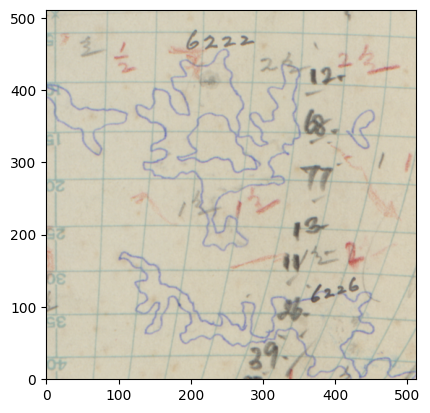

In [15]:
plt.imshow(images[6],origin='lower')

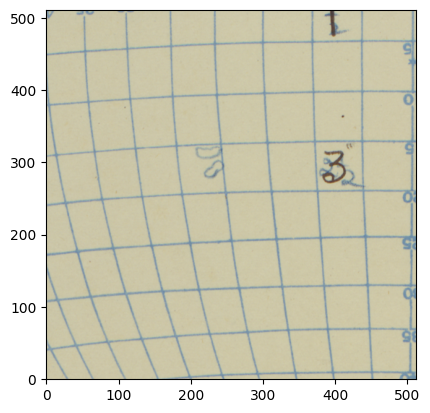

In [42]:
plt.imshow(images1[5],origin='lower') #5,6,9

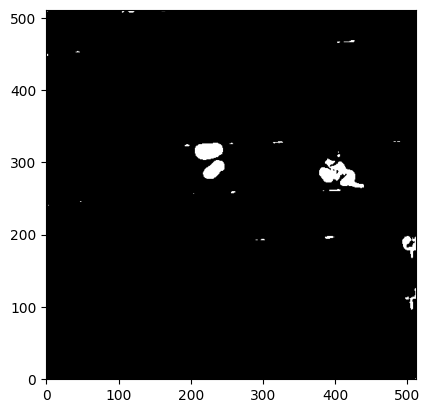

In [45]:
plt.imshow(masks1[5],origin='lower',cmap='gray') 

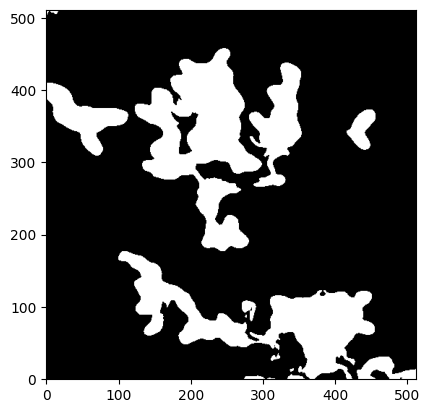

In [16]:
plt.imshow(masks[6],origin='lower',cmap='gray') #4,5,10,11 ,,6,7,8,9 ,, 9,7,6

/tmp/ipykernel_806130/97385686.py:26: UserWarning: linewidths is ignored by contourf
  ax3.contourf(masks[9],levels=[0.5, 1.5],alpha=0.1, colors='mediumvioletred', linestyles='-',origin='lower',linewidths=0.1)
/tmp/ipykernel_806130/97385686.py:40: UserWarning: linewidths is ignored by contourf
  ax1.contourf(masks[6],levels=[0.5, 1.5],alpha=0.1, colors='mediumvioletred', linestyles='-',origin='lower',linewidths=0.1)


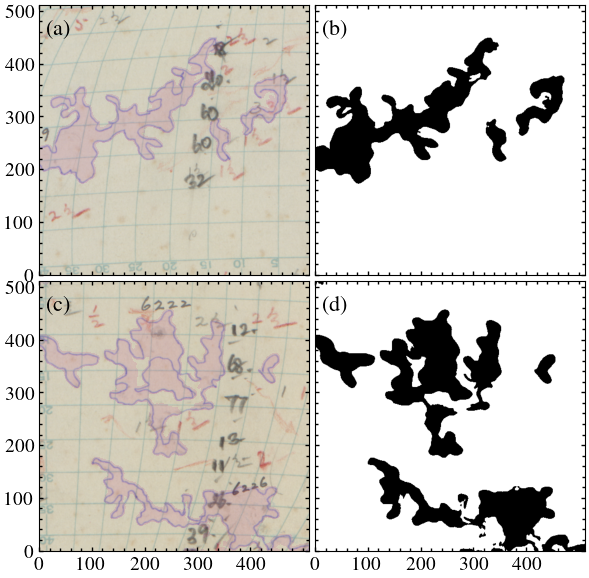

In [17]:
import os
import cv2
import numpy as np
from PIL import Image
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv2
import glob
import os, sys
import imutils
import matplotlib as mpl
mpl.style.use('bkj_style.mplstyle')

from matplotlib.colors import PowerNorm

# plot figure
fig=plt.figure(figsize = (6,6))
ax1 = fig.add_axes([0.1,0.1,0.45, 0.45])
ax2 = fig.add_axes([0.56,0.1,0.45, 0.45])
ax3 = fig.add_axes([0.1,0.56,0.45, 0.45])
ax4 = fig.add_axes([0.56,0.56,0.45, 0.45])

ax3.imshow(images[9],origin='lower',alpha=1,norm=PowerNorm(gamma=1.5))
#ax3.contour(masks[9],alpha=0.2, colors='crimson', linestyles='-',origin='lower',linewidths=0.03)
ax3.contourf(masks[9],levels=[0.5, 1.5],alpha=0.1, colors='mediumvioletred', linestyles='-',origin='lower',linewidths=0.1)
ax3.tick_params(axis='both', labelsize=14,labelbottom=False)
ax3.annotate('(a)', (15,455), fontsize=16)
ax3.set_xticks([0,100,200,300,400])
ax3.grid()

ax4.imshow(masks[9],origin='lower',cmap='gray_r')
ax4.tick_params(axis='both', labelsize=14,labelbottom=False,labelleft=False)
ax4.annotate('(b)', (15,455), fontsize=16)
ax4.set_xticks([0,100,200,300,400])
ax4.grid()

ax1.imshow(images[6],origin='lower',alpha=1,norm=PowerNorm(gamma=1.5))
#ax1.contour(masks[6],alpha=0.2, colors='crimson', linestyles='-',origin='lower',linewidths=0.03)
ax1.contourf(masks[6],levels=[0.5, 1.5],alpha=0.1, colors='mediumvioletred', linestyles='-',origin='lower',linewidths=0.1)
ax1.tick_params(axis='both', labelsize=14)
ax1.annotate('(c)', (15,455), fontsize=16)
ax1.set_xticks([0,100,200,300,400])
ax1.grid()



ax2.imshow(masks[6],origin='lower',cmap='gray_r')
ax2.tick_params(axis='both', labelsize=14,labelleft=False)
ax2.annotate('(d)', (15,455), fontsize=16)
ax2.set_xticks([0,100,200,300,400])
ax2.grid()

plt.savefig('plage_prediction_img.pdf', bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()



/tmp/ipykernel_1597189/3916951284.py:24: UserWarning: linewidths is ignored by contourf
  ax3.contourf(masks[9],levels=[0.5, 1.5],alpha=0.1, colors='mediumvioletred', linestyles='-',origin='lower',linewidths=0.1)


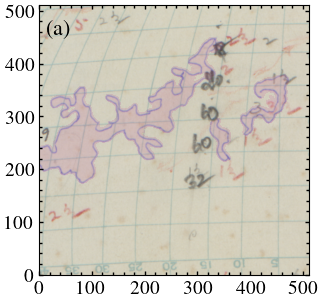

In [17]:
import os
import cv2
import numpy as np
from PIL import Image
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv2
import glob
import os, sys
import imutils
import matplotlib as mpl
mpl.style.use('bkj_style.mplstyle')

from matplotlib.colors import PowerNorm

# plot figure
fig=plt.figure(figsize = (6,6))
ax3 = fig.add_axes([0.1,0.56,0.45, 0.45])


ax3.imshow(images[9],origin='lower',alpha=1,norm=PowerNorm(gamma=1.5))
#ax3.contour(masks[9],alpha=0.2, colors='crimson', linestyles='-',origin='lower',linewidths=0.03)
ax3.contourf(masks[9],levels=[0.5, 1.5],alpha=0.1, colors='mediumvioletred', linestyles='-',origin='lower',linewidths=0.1)
ax3.tick_params(axis='both', labelsize=14)
ax3.annotate('(a)', (15,455), fontsize=16)
ax3.set_xticks([0,100,200,300,400,500])
ax3.grid()

plt.show()



/tmp/ipykernel_1597189/2483851917.py:24: UserWarning: linewidths is ignored by contourf
  ax3.contourf(masks1[5],levels=[0.5, 1.5],alpha=0.1, colors='mediumvioletred', linestyles='-',origin='lower',linewidths=0.1)


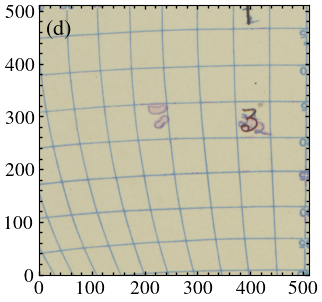

In [18]:
import os
import cv2
import numpy as np
from PIL import Image
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv2
import glob
import os, sys
import imutils
import matplotlib as mpl
mpl.style.use('bkj_style.mplstyle')

from matplotlib.colors import PowerNorm

# plot figure
fig=plt.figure(figsize = (6,6))
ax3 = fig.add_axes([0.1,0.56,0.45, 0.45])


ax3.imshow(images1[5],origin='lower',alpha=1,norm=PowerNorm(gamma=1.5))
#ax3.contour(masks[9],alpha=0.2, colors='crimson', linestyles='-',origin='lower',linewidths=0.03)
ax3.contourf(masks1[5],levels=[0.5, 1.5],alpha=0.1, colors='mediumvioletred', linestyles='-',origin='lower',linewidths=0.1)
ax3.tick_params(axis='both', labelsize=14)
ax3.annotate('(d)', (15,455), fontsize=16)
ax3.set_xticks([0,100,200,300,400,500])
ax3.grid()

plt.show()


In [23]:
import numpy as np


reshape = np.reshape(masks, (1, 4, 4, 512, 512))#221

# Initialize list to store reconstructed full images
full_image = []

# Loop through each image
for i in range(reshape.shape[0]):  # Iterate over the number of images
    # Initialize a blank canvas for the current image
    reconstructed_image = np.zeros((2048, 2048), dtype=reshape.dtype)
    
    # Map patches to their corresponding positions
    for x in range(4):  # Row index in the patch grid
        for y in range(4):  # Column index in the patch grid
            # Calculate the start and end positions for the patch in the reconstructed image
            x_start, x_end = x * 512, (x + 1) * 512
            y_start, y_end = y * 512, (y + 1) * 512
            
            # Place the patch into the reconstructed image
            reconstructed_image[x_start:x_end, y_start:y_end] = reshape[i, x, y]
    
    # Append the reconstructed image to the list
    full_image.append(reconstructed_image)

# Check the reconstructed images
for idx, img in enumerate(full_image):
    print(f"Reconstructed Image {idx + 1} Shape: {img.shape}")

Reconstructed Image 1 Shape: (2048, 2048)


In [24]:
import numpy as np


reshape1 = np.reshape(masks1, (1, 4, 4, 512, 512))#221

# Initialize list to store reconstructed full images
full_image1 = []

# Loop through each image
for i in range(reshape1.shape[0]):  # Iterate over the number of images
    # Initialize a blank canvas for the current image
    reconstructed_image1 = np.zeros((2048, 2048), dtype=reshape1.dtype)
    
    # Map patches to their corresponding positions
    for x in range(4):  # Row index in the patch grid
        for y in range(4):  # Column index in the patch grid
            # Calculate the start and end positions for the patch in the reconstructed image
            x_start, x_end = x * 512, (x + 1) * 512
            y_start, y_end = y * 512, (y + 1) * 512
            
            # Place the patch into the reconstructed image
            reconstructed_image1[x_start:x_end, y_start:y_end] = reshape1[i, x, y]
    
    # Append the reconstructed image to the list
    full_image1.append(reconstructed_image1)

# Check the reconstructed images
for idx, img in enumerate(full_image1):
    print(f"Reconstructed Image {idx + 1} Shape: {img.shape}")

Reconstructed Image 1 Shape: (2048, 2048)


In [25]:
import numpy as np

def mask_outside_circle(array, center, radius):
    """
    Remove (mask) values outside a given radius from a circle in a 2D array.

    Parameters:
    array (numpy.ndarray): The input 2D array.
    center (tuple): The (x, y) coordinates of the circle center.
    radius (float): The radius of the circle.

    Returns:
    numpy.ndarray: A 2D array with values outside the circle set to 0 (or masked).
    """
    x_center, y_center = center
    
    # Create a grid of indices matching the array's shape
    y_indices, x_indices = np.ogrid[:array.shape[0], :array.shape[1]]

    # Calculate the distance from the center for each point
    distance_from_center = np.sqrt((x_indices - x_center)**2 + (y_indices - y_center)**2)

    # Mask values outside the radius
    mask = distance_from_center <= radius

    # Apply the mask: keep values inside the circle, set others to 0
    masked_array = np.where(mask, array, 0)

    return masked_array


In [26]:
reconstructed = np.array(full_image)

In [27]:
reconstructed1 = np.array(full_image1)

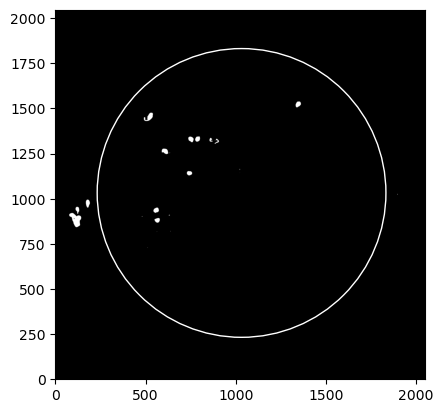

In [13]:
from matplotlib.patches import Circle
fig, ax = plt.subplots()
ax.imshow(reconstructed[0],cmap='gray',origin='lower')
circle = Circle((1032,1032),800, color='white', fill=False, linewidth=1)
ax.add_patch(circle)

/tmp/ipykernel_1597189/189496894.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


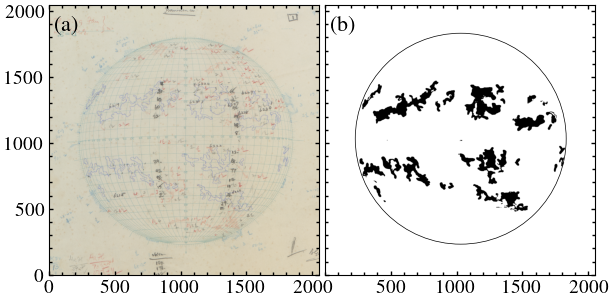

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import imutils
from PIL import Image
import matplotlib as mpl
mpl.style.use('bkj_style.mplstyle')

from matplotlib.patches import Circle

fig=plt.figure(figsize = (6,6))
ax1 = fig.add_axes([0.56,0.1,0.45, 0.45])
ax2 = fig.add_axes([0.1,0.1,0.45, 0.45])

reconstruct = cv2.imread('/home/dibya/ML_project/prediction_patch/sch_19370102_0849_kkkk.tif', cv2.IMREAD_COLOR)
reconstruct = cv2.cvtColor(reconstruct, cv2.COLOR_BGR2RGB)
reconstruct = cv2.flip(reconstruct, 0)
reconstruct = Image.fromarray(reconstruct)
reconstruct = reconstruct.resize((2048,2048))

# Display images
ax1.imshow(reconstructed[0],cmap='gray_r',origin='lower')
ax1.annotate('(b)', (45,1850), fontsize=16)
ax1.tick_params(axis='both', labelsize=14,labelleft= False)
ax1.set_xticks([500,1000,1500,2000])
ax1.set_yticks([0,500,1000,1500,2000])
circle = Circle((1032,1032),800, color='black', fill=False, linewidth=0.5)
ax1.add_patch(circle)
ax1.grid()

ax2.imshow(reconstruct,origin='lower')
ax2.contour(reconstructed[0],alpha=0.07, colors='crimson', linestyles='-',origin='lower',linewidths=0.01)
ax2.annotate('(a)', (45,1850), fontsize=16)
ax2.tick_params(axis='both', labelsize=14)
ax2.set_xticks([0,500,1000,1500,2000])
ax2.set_yticks([0,500,1000,1500,2000])
ax2.grid()

plt.tight_layout()
plt.savefig('predicted_raw_img.pdf', bbox_inches='tight', pad_inches=0, dpi=300)


/tmp/ipykernel_1597189/3996551089.py:53: UserWarning: linewidths is ignored by contourf
  ax2.contourf(reconstructed[0], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred',
/tmp/ipykernel_1597189/3996551089.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


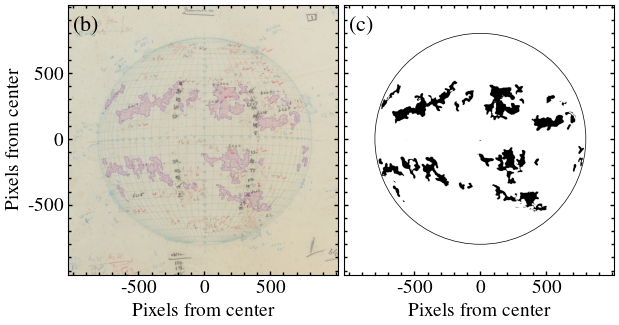

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import imutils
from PIL import Image
import matplotlib as mpl
mpl.style.use('bkj_style.mplstyle')

from matplotlib.patches import Circle
from matplotlib.colors import PowerNorm

# Create figure
fig = plt.figure(figsize=(6, 6))
ax1 = fig.add_axes([0.56, 0.1, 0.45, 0.45])  # Right subplot
ax2 = fig.add_axes([0.1, 0.1, 0.45, 0.45])   # Left subplot

# Load and process image
reconstruct = cv2.imread('/home/dibya/ML_project/prediction_patch/sch_19370102_0849_kkkk.tif', cv2.IMREAD_COLOR)
reconstruct = cv2.cvtColor(reconstruct, cv2.COLOR_BGR2RGB)
reconstruct = cv2.flip(reconstruct, 0)
reconstruct = Image.fromarray(reconstruct)
reconstruct = reconstruct.resize((2048, 2048))

# Define center coordinates (adjust these if needed)
center_x, center_y = 1032, 1032  # Center of your image/circle 

# Function to convert absolute pixels to relative coordinates
def rel_pix(pixel, center):
    return pixel - center

# --- Right Subplot (ax1) ---
ax1.imshow(reconstructed[0], cmap='gray_r', origin='lower', alpha=1, norm=PowerNorm(gamma=1.5))
ax1.annotate('(c)', (45, 1850), fontsize=16)

# Set ticks in relative coordinates (-500, 0, 500)
relative_ticks = [-500, 0, 500]
xticks_pixels = [center_x + x for x in relative_ticks]
yticks_pixels = [center_y + y for y in relative_ticks]

ax1.set_xticks(xticks_pixels)
ax1.set_yticks(yticks_pixels)
ax1.set_xticklabels([f"{x:.0f}" for x in relative_ticks])
ax1.set_yticklabels([f"{y:.0f}" for y in relative_ticks])

ax1.tick_params(axis='both', labelsize=14, labelleft=False)
circle = Circle((center_x, center_y), 800, color='black', fill=False, linewidth=0.5)
ax1.add_patch(circle)
ax1.grid()

# --- Left Subplot (ax2) ---
ax2.imshow(reconstruct, origin='lower')
ax2.contourf(reconstructed[0], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred', 
             linestyles='-', origin='lower', linewidths=0.01)
ax2.annotate('(b)', (45, 1850), fontsize=16)

# Use the same relative ticks for ax2
ax2.set_xticks(xticks_pixels)
ax2.set_yticks(yticks_pixels)
ax2.set_xticklabels([f"{x:.0f}" for x in relative_ticks])
ax2.set_yticklabels([f"{y:.0f}" for y in relative_ticks])

ax2.tick_params(axis='both', labelsize=14)
ax2.grid()

# Add axis labels (optional)
ax1.set_xlabel('Pixels from center', fontsize=14)
ax1.set_ylabel('Pixels from center', fontsize=14)
ax2.set_xlabel('Pixels from center', fontsize=14)
ax2.set_ylabel('Pixels from center', fontsize=14)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1597189/3041110281.py:46: UserWarning: linewidths is ignored by contourf
  ax2.contourf(reconstructed1[0], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred',
/tmp/ipykernel_1597189/3041110281.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


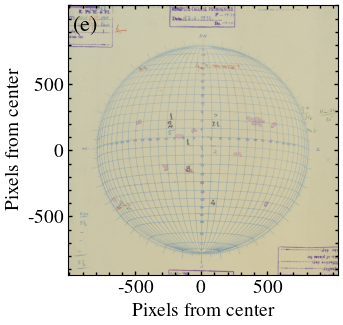

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import imutils
from PIL import Image
import matplotlib as mpl
mpl.style.use('bkj_style.mplstyle')

from matplotlib.patches import Circle
from matplotlib.colors import PowerNorm

# Create figure
fig = plt.figure(figsize=(6, 6))

ax2 = fig.add_axes([0.1, 0.1, 0.45, 0.45])   # Left subplot

# Load and process image
reconstruct1 = cv2.imread('/home/dibya/ML_project/prediction_patch1/sch_19750223_0000_xmmm.tif', cv2.IMREAD_COLOR)
reconstruct1 = cv2.cvtColor(reconstruct1, cv2.COLOR_BGR2RGB)
reconstruct1 = cv2.flip(reconstruct1, 0)
reconstruct1 = Image.fromarray(reconstruct1)
reconstruct1 = reconstruct1.resize((2048, 2048))

# Define center coordinates (adjust these if needed)
center_x1, center_y1 = 1008, 944  # Center of your image/circle#[1008.0][944.0][800.0]

# Function to convert absolute pixels to relative coordinates
def rel_pix(pixel, center):
    return pixel - center



# Set ticks in relative coordinates (-500, 0, 500)
relative_ticks1 = [-500, 0, 500]
xticks_pixels1 = [center_x1 + x for x in relative_ticks1]
yticks_pixels1 = [center_y1 + y for y in relative_ticks1]



circle1 = Circle((center_x1, center_y1), 800, color='black', fill=False, linewidth=0.5)


# --- Left Subplot (ax2) ---
ax2.imshow(reconstruct1, origin='lower')
ax2.contourf(reconstructed1[0], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred', 
             linestyles='-', origin='lower', linewidths=0.01)
ax2.annotate('(e)', (45, 1850), fontsize=16)

# Use the same relative ticks for ax2
ax2.set_xticks(xticks_pixels1)
ax2.set_yticks(yticks_pixels1)
ax2.set_xticklabels([f"{x:.0f}" for x in relative_ticks1])
ax2.set_yticklabels([f"{y:.0f}" for y in relative_ticks1])

ax2.tick_params(axis='both', labelsize=14)
ax2.grid()

# Add axis labels (optional)

ax2.set_xlabel('Pixels from center', fontsize=14)
ax2.set_ylabel('Pixels from center', fontsize=14)

plt.tight_layout()
plt.show()

In [14]:
import h5py
from skimage.transform import resize

In [15]:
from skimage.filters import threshold_otsu
from datetime import datetime
for i in range (reconstructed.shape[0]):

    
    array = reconstructed[i]
    
    center = (int(x0_main[i]), int(y0_main[i]))  # Center of the circle
    radius = int(rad_main[i])         # Radius of the circle
    
    
     # Mask the array
    
    #result = mask_outside_circle(array, (center), radius)
    result = mask_outside_circle(array, (1024,1024), 1024)
     
    #Step 1: Check if the array is empty
    if result.size == 0:
       print("Warning: The input array is empty. Skipping normalization.")
       continue
   
    result_resized = result
    # Find an optimal threshold using Otsu's method
    otsu_thresh = threshold_otsu(result_resized)

    # Apply the threshold to convert to a binary mask
    result_resized = (result_resized > otsu_thresh).astype(np.uint8)
     
    from matplotlib.patches import Circle
    
    name_without_tif = name_image[i].replace(".tif", "")  # Remove ".tif"
    
   #  with h5py.File(f"/home/dibya/ML_project/prediction_img/{name_without_tif}.h5", "w") as f:   
   #    f.create_dataset("mask", data=result_resized)
    with h5py.File(f"/home/dibya/ML_project/activity_prediction/{name_without_tif}.h5", "w") as f:   
      f.create_dataset("mask", data=result_resized)
   

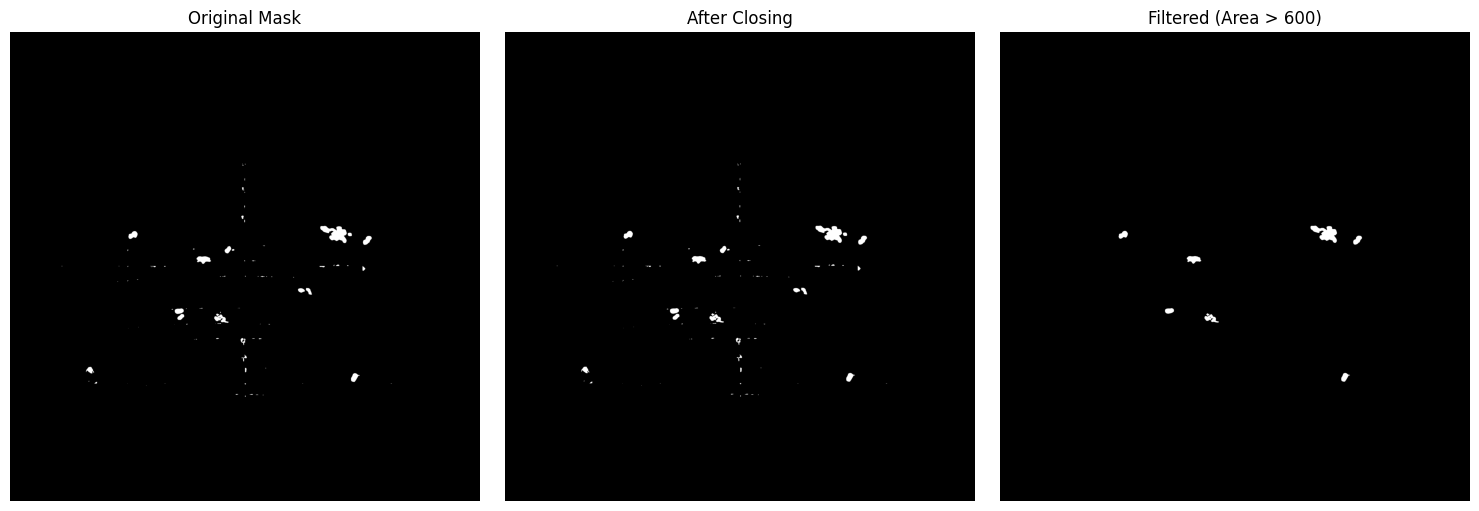

Processed file with timestamp: 1975-02-23T00:00:00


In [28]:
import h5py
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from datetime import datetime

def process_sunchart_mask(h5_file_path, area_threshold=600, kernel_size=(2,2), iterations=1): #80, 600
    """
    Process a sunchart mask from an HDF5 file with morphological operations and area filtering
    
    Args:
        h5_file_path (str): Path to the .h5 file
        area_threshold (int): Minimum area for connected components to keep
        kernel_size (tuple): Size of morphological kernel
        iterations (int): Number of iterations for morphological operations
        
    Returns:
        tuple: (original_mask, closed_mask, filtered_mask, timestamp)
    """
    with h5py.File(h5_file_path, "r") as f:
        # Read and preprocess mask
        mask = f["mask"][:].clip(max=1)
        #mask = cv2.flip(mask, 1)  # Flip horizontally
        
        # Morphological closing
        kernel = np.ones(kernel_size, np.uint8)
        closing = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=iterations)
        
        # Connected component analysis
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closing.astype(np.uint8), connectivity=8)#8
        
        # Filter by area
        filtered_mask = np.zeros_like(closing, dtype=np.uint8)
        for i in range(1, num_labels):  # Skip background (label 0)
            if stats[i, cv2.CC_STAT_AREA] >= area_threshold:
                filtered_mask[labels == i] = 1
                
        # Extract timestamp from filename
        filename = os.path.basename(h5_file_path)
        timestamp_str = os.path.splitext(filename)[0][:16]
        timestamp = datetime.strptime(timestamp_str, "sch_%Y%m%d_%H%M")
        
        return mask, closing, filtered_mask, timestamp

def plot_mask_results(original, processed, final, title_suffix=""):
    """Plot the three stages of mask processing"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    titles = ['Original Mask', 'After Closing', f'Filtered {title_suffix}']
    for ax, img, title in zip(axes, [original, processed, final], titles):
        ax.imshow(img, origin='lower', cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    h5_file_path = "/home/dibya/ML_project/prediction_img/sch_19750223_0000_xmmm.h5"  # Replace with your file path
    area_threshold = 600  # Adjust as needed #600,80
    
    # Process the mask
    original_mask, closed_mask, filtered_mask, timestamp = process_sunchart_mask(
        h5_file_path, 
        area_threshold=area_threshold
    )
    
    # Plot results
    plot_title = f"(Area > {area_threshold})"
    plot_mask_results(original_mask, closed_mask, filtered_mask, plot_title)
    
    print(f"Processed file with timestamp: {timestamp.isoformat()}")

In [19]:
import h5py
import glob
import numpy as np
from skimage.filters import threshold_otsu
import os
import cv2
import matplotlib.pyplot as plt
from datetime import datetime


# Path to directory containing .h5 files
h5_files = sorted(glob.glob("/home/dibya/ML_project/sunchart_activity_prediction/*.h5"))

# Loop through each file and read the data
for k,h5_file in enumerate(h5_files):
    with h5py.File(h5_file, "r") as f:
        mask = f["mask"][:]  # Read mask
        mask = mask.clip(max=1)
        
        mask = cv2.flip(mask,1)
        # Perform morphological closing
        kernel1 = np.ones((2, 2), np.uint8)
        closing = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel1, iterations=1)#3

        # Apply connected component analysis
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(closing, connectivity=8)

        # Define area threshold
        area_threshold = 600  # Set your desired threshold here #80,600

        # Create a mask to keep only components above the area threshold
        filtered_mask = np.zeros_like(closing, dtype=np.uint8)
        for i in range(1, num_labels):  # Skip background (label 0)
           if stats[i, cv2.CC_STAT_AREA] >= area_threshold:
              filtered_mask[labels == i] = 1  # Set the region to white


In [14]:
import h5py
import glob
import numpy as np
import cv2
import os
from datetime import datetime

# Initialize list to store filtered masks
mask_filtered = []

# Path to directory containing .h5 files
h5_files = sorted(glob.glob("/home/dibya/ML_project/activity_prediction/*.h5"))

# Parameters
area_threshold = 600  # Set your desired threshold here #80,600
kernel_size = (2, 2)  # for morphological closing

# Loop through each file and read the data
for h5_file in h5_files:
    with h5py.File(h5_file, "r") as f:
        # Read and preprocess mask
        mask = f["mask"][:].clip(max=1)
        #mask = cv2.flip(mask, 1)
        
        # Perform morphological closing
        kernel = np.ones(kernel_size, np.uint8)
        closing = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
        
        # Apply connected component analysis
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            closing.astype(np.uint8), connectivity=8)
        
        # Create filtered mask
        filtered_mask = np.zeros_like(closing, dtype=np.uint8)
        for i in range(1, num_labels):  # Skip background (label 0)
            if stats[i, cv2.CC_STAT_AREA] >= area_threshold:
                filtered_mask[labels == i] = 1
        
        # Append the filtered mask to our list
        mask_filtered.append(filtered_mask)
        
        # Optional: Save or display the filtered mask
        # cv2.imwrite(f"filtered_mask_{k}.png", filtered_mask * 255)
        # plt.imshow(filtered_mask, cmap='gray')
        # plt.show()

# Now mask_filtered contains all processed masks
print(f"Processed {len(mask_filtered)} masks")

Processed 3 masks


In [15]:
filtered_img = np.array(mask_filtered)

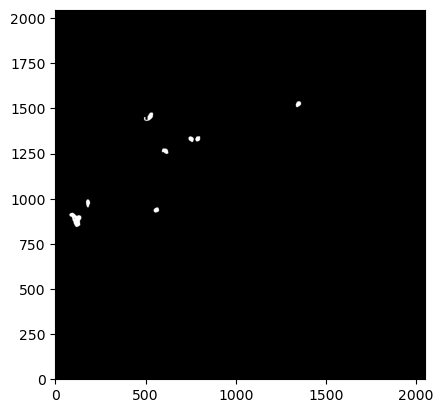

In [5]:
plt.imshow(filtered_img[0], origin='lower', cmap='gray')

/tmp/ipykernel_1513806/1468006821.py:53: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax1.contour(filtered_img[2],alpha=0.07, colors='crimson', linestyles='-',origin='lower',linewidths=0.01, rasterized=True)
/tmp/ipykernel_1513806/1468006821.py:63: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax4.contour(filtered_img[2],alpha=0.2, colors='crimson', linestyles='-',origin='lower',linewidths=0.2,  rasterized=True)
/tmp/ipykernel_1513806/1468006821.py:73: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax2.contour(filtered_img[1],alpha=0.07, colors='crimson', linestyles='-',origin='lower',linewidths=0.01, rasterized=True)
/tmp/ipykernel_1513806/1468006821.py:83: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax5.contour(filtered_img[1],alpha=0.2, colors='crimson', linestyles='-',origin='lower',linewidths=0.2, rasterized=True)
/tmp/ipykernel_1513806/1468006821.py:93: UserWarnin

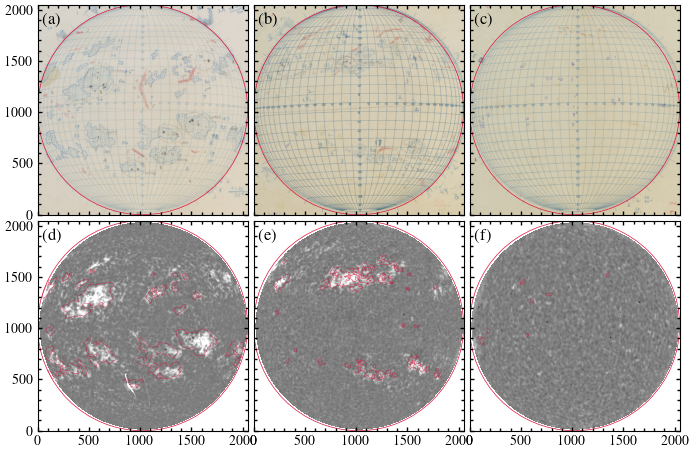

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import imutils
from PIL import Image
import matplotlib as mpl
mpl.style.use('bkj_style.mplstyle')

from matplotlib.patches import Circle

# read 'sav' files
sav_data_max = readsav("/home/dibya/ML_project/plage_overlap_19580109_0824.sav") 
sav_data_middle = readsav("/home/dibya/ML_project/plage_overlap_19560101_0746.sav") 
sav_data_min = readsav("/home/dibya/ML_project/plage_overlap_19540101_1352.sav")

fig=plt.figure(figsize = (6,6))

ax1 = fig.add_axes([0.01,0.37,0.35, 0.35])
ax2 = fig.add_axes([0.37,0.37,0.35, 0.35])
ax3 = fig.add_axes([0.73,0.37,0.35, 0.35])
ax4 = fig.add_axes([0.01,0.01,0.35, 0.35])
ax5 = fig.add_axes([0.37,0.01,0.35, 0.35])
ax6 = fig.add_axes([0.73,0.01,0.35, 0.35])

reconstruct_maxmima = cv2.imread('/home/dibya/ML_project/maxima_activity_img/sch_19580109_0812_kkkk.tif', cv2.IMREAD_COLOR) 
reconstruct_maxmima = cv2.cvtColor(reconstruct_maxmima, cv2.COLOR_BGR2RGB)
reconstruct_maxmima = cv2.flip(reconstruct_maxmima, 0)
reconstruct_maxmima = imutils.rotate(reconstruct_maxmima,angle=0.0)
reconstruct_maxmima = reconstruct_maxmima[3024-2424:3024+2424,3048-2424:3048+2424]
reconstruct_maxmima = Image.fromarray(reconstruct_maxmima)
reconstruct_maxmima = reconstruct_maxmima.resize((2048,2048))

reconstruct_middle = cv2.imread('/home/dibya/ML_project/middle_activity_img/sch_19560101_0750_kkkk.tif', cv2.IMREAD_COLOR) 
reconstruct_middle = cv2.cvtColor(reconstruct_middle, cv2.COLOR_BGR2RGB)
reconstruct_middle = cv2.flip(reconstruct_middle, 0)
reconstruct_middle = imutils.rotate(reconstruct_middle,angle=-1.0)
reconstruct_middle = reconstruct_middle[2976-2400:2976+2400,3072-2400:3072+2400]
reconstruct_middle = Image.fromarray(reconstruct_middle)
reconstruct_middle = reconstruct_middle.resize((2048,2048))

reconstruct_minimum = cv2.imread('/home/dibya/ML_project/minimum_activity_img/sch_19540101_0803_kkkk.tif', cv2.IMREAD_COLOR) 
reconstruct_minimum = cv2.cvtColor(reconstruct_minimum, cv2.COLOR_BGR2RGB)
reconstruct_minimum = cv2.flip(reconstruct_minimum, 0)
reconstruct_minimum = imutils.rotate(reconstruct_minimum,angle=-1.0)
reconstruct_minimum = reconstruct_minimum[3072-2400:3072+2400,2952-2400:2952+2400]
reconstruct_minimum = Image.fromarray(reconstruct_minimum)
reconstruct_minimum = reconstruct_minimum.resize((2048,2048))


# Display images
ax1.imshow(reconstruct_maxmima,origin='lower',rasterized=True)
ax1.contour(filtered_img[2],alpha=0.07, colors='crimson', linestyles='-',origin='lower',linewidths=0.01, rasterized=True)
ax1.annotate('(a)', (45,1850), fontsize=12)
ax1.tick_params(axis='both', labelsize=10,labelbottom=False)
ax1.set_xticks([0,500,1000,1500,2000])
ax1.set_yticks([0,500,1000,1500,2000])
circle = Circle((1024,1024),1024, color='crimson', fill=False, linewidth=0.5,   rasterized=True)
ax1.add_patch(circle)
ax1.grid()

ax4.imshow(sav_data_max['resized_data'],cmap='gray',origin='lower',vmin=-0.5,vmax=0.5, rasterized=True)
ax4.contour(filtered_img[2],alpha=0.2, colors='crimson', linestyles='-',origin='lower',linewidths=0.2,  rasterized=True)
ax4.annotate('(d)', (45,1850), fontsize=12)
ax4.tick_params(axis='both', labelsize=10)
ax4.set_xticks([0,500,1000,1500,2000])
ax4.set_yticks([0,500,1000,1500,2000])
circle1 = Circle((1024,1024),1024, color='crimson', fill=False, linewidth=0.5, rasterized=True)
ax4.add_patch(circle1)
ax4.grid()

ax2.imshow(reconstruct_middle,origin='lower',rasterized=True)
ax2.contour(filtered_img[1],alpha=0.07, colors='crimson', linestyles='-',origin='lower',linewidths=0.01, rasterized=True)
ax2.annotate('(b)', (45,1850), fontsize=12)
ax2.tick_params(axis='both', labelsize=10,labelleft= False,labelbottom=False)
ax2.set_xticks([500,1000,1500,2000])
ax2.set_yticks([0,500,1000,1500,2000])
circle1 = Circle((1024,1024),1024, color='crimson', fill=False, linewidth=0.5, rasterized=True)
ax2.add_patch(circle1)
ax2.grid()

ax5.imshow(sav_data_middle['resized_data'],cmap='gray',origin='lower',vmin=-0.5,vmax=0.5, rasterized=True)
ax5.contour(filtered_img[1],alpha=0.2, colors='crimson', linestyles='-',origin='lower',linewidths=0.2, rasterized=True)
ax5.annotate('(e)', (45,1850), fontsize=12)
ax5.tick_params(axis='both', labelsize=10,labelleft=False)
ax5.set_xticks([0,500,1000,1500,2000])
ax5.set_yticks([0,500,1000,1500,2000])
circle2 = Circle((1024,1024),1024, color='crimson', fill=False, linewidth=0.5, rasterized=True)
ax5.add_patch(circle2)
ax5.grid()

ax3.imshow(reconstruct_minimum,origin='lower',rasterized=True)
ax3.contour(filtered_img[0],alpha=0.07, colors='crimson', linestyles='-',origin='lower',linewidths=0.01, rasterized=True)
ax3.annotate('(c)', (45,1850), fontsize=12)
ax3.tick_params(axis='both', labelsize=10,labelleft= False,labelbottom=False)
ax3.set_xticks([500,1000,1500,2000])
ax3.set_yticks([0,500,1000,1500,2000])
circle3 = Circle((1024,1024),1024, color='crimson', fill=False, linewidth=0.5, rasterized=True)
ax3.add_patch(circle3)
ax3.grid()

ax6.imshow(sav_data_min['resized_data'],cmap='gray',origin='lower',vmin=-0.5,vmax=0.5, rasterized=True)
ax6.contour(filtered_img[0],alpha=0.2, colors='crimson', linestyles='-',origin='lower',linewidths=0.2, rasterized=True)
ax6.annotate('(f)', (45,1850), fontsize=12)
ax6.tick_params(axis='both', labelsize=10,labelleft=False)
ax6.set_xticks([0,500,1000,1500,2000])
ax6.set_yticks([0,500,1000,1500,2000])
circle4 = Circle((1024,1024),1024, color='crimson', fill=False, linewidth=0.5,rasterized=True)
ax6.add_patch(circle4)
ax6.grid()

plt.tight_layout()
plt.savefig('activity_comp_img.pdf', bbox_inches='tight', pad_inches=0, dpi=200)

/tmp/ipykernel_1473739/4103114617.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


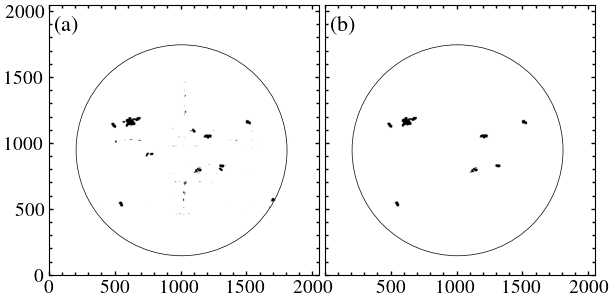

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import imutils
from PIL import Image
import matplotlib as mpl
mpl.style.use('bkj_style.mplstyle')

from matplotlib.patches import Circle

fig=plt.figure(figsize = (6,6))

ax1 = fig.add_axes([0.1,0.1,0.45, 0.45])
ax2 = fig.add_axes([0.56,0.1,0.45, 0.45])


# Display images
ax1.imshow(original_mask,cmap='gray_r',origin='lower')
ax1.annotate('(a)', (45,1850), fontsize=16)
ax1.tick_params(axis='both', labelsize=14)
ax1.set_xticks([0,500,1000,1500,2000])
ax1.set_yticks([0,500,1000,1500,2000])
circle = Circle((1008,944),800, color='black', fill=False, linewidth=0.5)
ax1.add_patch(circle)
ax1.grid()

ax2.imshow(filtered_mask,cmap='gray_r',origin='lower')
ax2.annotate('(b)', (45,1850), fontsize=16)
ax2.tick_params(axis='both', labelsize=14,labelleft= False)
ax2.set_xticks([500,1000,1500,2000])
ax2.set_yticks([0,500,1000,1500,2000])
circle1 = Circle((1008,944),800, color='black', fill=False, linewidth=0.5)
ax2.add_patch(circle1)
ax2.grid()

plt.tight_layout()
plt.savefig('predicted_processed_img.pdf', bbox_inches='tight', pad_inches=0, dpi=300)

/tmp/ipykernel_1549686/3705417853.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


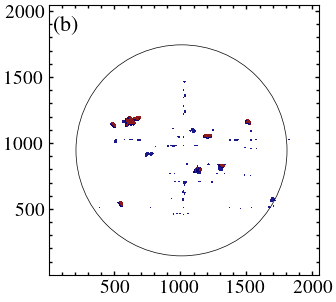

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import imutils
from PIL import Image
import matplotlib as mpl
mpl.style.use('bkj_style.mplstyle')

from matplotlib.patches import Circle

fig = plt.figure(figsize=(6,6))

# Create axes
ax2 = fig.add_axes([0.56, 0.1, 0.45, 0.45])



# Display filtered mask (right plot)
#ax2.imshow(original_mask-filtered_mask, cmap='gray_r', vmin=0, vmax=1,origin='lower')
ax2.contourf(filtered_mask, levels=[0.5, 1.5], colors='maroon', alpha=0.9, origin='lower')
ax2.annotate('(b)', (45, 1850), fontsize=16)
ax2.tick_params(axis='both', labelsize=14)
ax2.set_xticks([500, 1000, 1500, 2000])
ax2.set_yticks([0, 500, 1000, 1500, 2000])
circle1 = Circle((1008, 944), 800, color='black', fill=False, linewidth=0.5)
ax2.add_patch(circle1)
ax2.grid()

# Overlay filtered_mask on original_mask in ax1 with a different color
ax2.contourf(original_mask-filtered_mask, levels=[0.5, 1.5],colors='navy', alpha=0.9, origin='lower')  # Semi-transparent red overlay

plt.tight_layout()
plt.savefig('predicted_processed_img.pdf', bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

/tmp/ipykernel_1513806/565449446.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


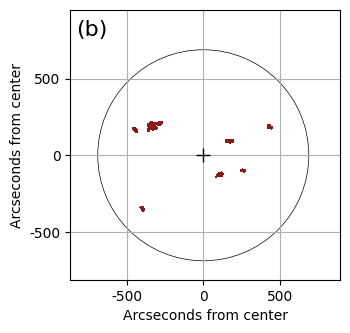

In [10]:
# Plate scale and center coordinates
plate_scale = 0.86  # arcseconds per pixel
center_x, center_y = 1008, 944  # Center coordinates in pixels

# Create figure
fig = plt.figure(figsize=(6, 6))
ax2 = fig.add_axes([0.56, 0.1, 0.45, 0.45])

# Convert arcseconds to pixel offsets from center
def arcsec_to_pix_offset(arcsec):
    return arcsec / plate_scale

# Display contour plot (in pixel coordinates)
ax2.contourf(filtered_mask, levels=[0.5, 1.5], colors='maroon', alpha=0.9, origin='lower')

# Set custom tick positions in arcseconds
desired_arcsecs = [-1000,-500, 0, 500,1000]

# Calculate corresponding pixel positions
xticks_pixels = [center_x + arcsec_to_pix_offset(a) for a in desired_arcsecs]
yticks_pixels = [center_y + arcsec_to_pix_offset(a) for a in desired_arcsecs]

ax2.set_xticks(xticks_pixels)
ax2.set_yticks(yticks_pixels)
ax2.set_xticklabels([f"{a:.0f}" for a in desired_arcsecs])
ax2.set_yticklabels([f"{a:.0f}" for a in desired_arcsecs])

# Add axis labels
ax2.set_xlabel('Arcseconds from center')
ax2.set_ylabel('Arcseconds from center')

# Add circle (in pixel coordinates)
circle_radius_pixels = 800
circle1 = Circle((center_x, center_y), circle_radius_pixels,
                color='black', fill=False, linewidth=0.5)
ax2.add_patch(circle1)

# Add center marker
ax2.plot(center_x, center_y, 'k+', markersize=10)

# Add annotation (in pixel coordinates)
ax2.annotate('(b)', 
             (45, 1850),  # Pixel coordinates
             fontsize=16)

ax2.grid()
plt.tight_layout()
#plt.savefig('predicted_processed_img.pdf', bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

/tmp/ipykernel_1560526/2376724996.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


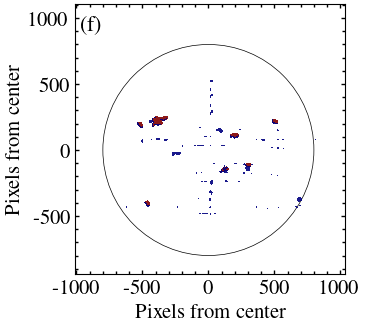

In [58]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

import matplotlib as mpl
mpl.style.use('bkj_style.mplstyle')

# Center coordinates
center_x, center_y = 1008, 944  # Your center coordinates in pixels

# Create figure
fig = plt.figure(figsize=(6, 6))
ax2 = fig.add_axes([0.56, 0.1, 0.45, 0.45])

# Display contour plot
ax2.contourf(filtered_mask, levels=[0.5, 1.5], colors='maroon', alpha=0.9, origin='lower')

# Set ticks in relative pixel coordinates (-500, 0, 500)
xticks_relative = [-1000,-500, 0, 500,1000]
yticks_relative = [-1000,-500, 0, 500,1000]

# Convert relative ticks back to absolute pixel positions for placement
xticks_pixels = [center_x + x for x in xticks_relative]
yticks_pixels = [center_y + y for y in yticks_relative]

ax2.set_xticks(xticks_pixels)
ax2.set_yticks(yticks_pixels)
ax2.set_xticklabels([f"{x:.0f}" for x in xticks_relative])
ax2.set_yticklabels([f"{y:.0f}" for y in yticks_relative])

# Add axis labels
ax2.set_xlabel('Pixels from center')
ax2.set_ylabel('Pixels from center')

# Add circle (in absolute pixel coordinates)
circle_radius = 800
circle1 = Circle((center_x, center_y), circle_radius, 
                color='black', fill=False, linewidth=0.5)
ax2.add_patch(circle1)

ax2.annotate('(f)', 
             (45, 1850),  # Pixel coordinates
             fontsize=16)
ax2.contourf(original_mask-filtered_mask, levels=[0.5, 1.5],colors='navy', alpha=0.9, origin='lower')  # Semi-transparent red overlay

ax2.grid()
plt.tight_layout()
plt.show()

/tmp/ipykernel_912864/2198651606.py:40: UserWarning: linewidths is ignored by contourf
  ax_a.contourf(masks[9], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred',
/tmp/ipykernel_912864/2198651606.py:40: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax_a.contourf(masks[9], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred',
/tmp/ipykernel_912864/2198651606.py:65: UserWarning: linewidths is ignored by contourf
  ax_b.contourf(reconstructed[0], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred',
/tmp/ipykernel_912864/2198651606.py:65: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax_b.contourf(reconstructed[0], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred',
/tmp/ipykernel_912864/2198651606.py:99: UserWarning: linewidths is ignored by contourf
  ax_d.contourf(masks1[5], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred',
/tmp/ipykernel_912864/2198651606.py:99: UserWarning: The following kwargs were not use

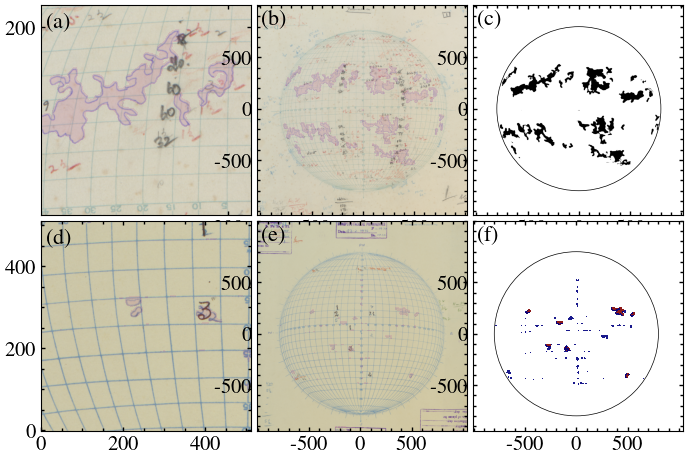

In [29]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Circle
from matplotlib.colors import PowerNorm
from PIL import Image, ImageEnhance

mpl.style.use('bkj_style.mplstyle')

from matplotlib.colors import PowerNorm

# # Create figure with 3 columns and 2 rows
# fig = plt.figure(figsize=(12, 8))
# plt.subplots_adjust(wspace=0.3, hspace=0.3)

fig=plt.figure(figsize = (6,6))

ax_a = fig.add_axes([0.01,0.37,0.35, 0.35])
ax_b = fig.add_axes([0.37,0.37,0.35, 0.35])
ax_c = fig.add_axes([0.73,0.37,0.35, 0.35])
ax_d = fig.add_axes([0.01,0.01,0.35, 0.35])
ax_e = fig.add_axes([0.37,0.01,0.35, 0.35])
ax_f = fig.add_axes([0.73,0.01,0.35, 0.35])


# Define center coordinates for different plots
center1 = (1032, 1032)  # For plots c, b
center2 = (1008, 944)   # For plots e, f
center3 = (256, 256)    # For plots a, d (assuming 512x512 images)

def rel_pix(pixel, center):
    return pixel - center


# --- Plot (a) ---
#ax_a = plt.subplot2grid((2, 3), (0, 0))
ax_a.imshow(images[9], origin='lower', alpha=1, norm=PowerNorm(gamma=1.5),rasterized=True)
ax_a.contourf(masks[9], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred', 
              linestyles='-', origin='lower', linewidths=0.1,rasterized=True)
#set_relative_ticks(ax_a, *center3)
center_xa, center_ya = 256, 256  # Center of your image/circle#[1008.0][944.0][800.0]
# Function to convert absolute pixels to relative coordinates
# Set ticks in relative coordinates (-500, 0, 500)
relative_ticksa = [200]
xticks_pixelsa = [center_xa + x for x in relative_ticksa]
yticks_pixelsa = [center_ya + y for y in relative_ticksa]
# Use the same relative ticks for ax2
ax_a.set_xticks(xticks_pixelsa)
ax_a.set_yticks(yticks_pixelsa)
ax_a.set_xticklabels([f"{x:.0f}" for x in relative_ticksa])
ax_a.set_yticklabels([f"{y:.0f}" for y in relative_ticksa])
ax_a.annotate('(a)', (15, 455), fontsize=16)
ax_a.grid()

# --- Plot (b) ---
#ax_b = plt.subplot2grid((2, 3), (0, 1))
reconstruct = cv2.imread('/home/dibya/ML_project/prediction_patch/sch_19370102_0849_kkkk.tif', cv2.IMREAD_COLOR)
reconstruct = cv2.cvtColor(reconstruct, cv2.COLOR_BGR2RGB)
reconstruct = cv2.flip(reconstruct, 0)
reconstruct = Image.fromarray(reconstruct).resize((2048, 2048))

ax_b.imshow(reconstruct, origin='lower',alpha=1, norm=PowerNorm(gamma=1.5),rasterized=True)
ax_b.contourf(reconstructed[0], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred', 
              linestyles='-', origin='lower', linewidths=0.01,rasterized=True)
center_x, center_y = 1032, 1032  # Center of your image/circle#[1008.0][944.0][800.0]

# Function to convert absolute pixels to relative coordinates
# Set ticks in relative coordinates (-500, 0, 500)
relative_ticks = [-500, 0, 500]
xticks_pixels = [center_x + x for x in relative_ticks]
yticks_pixels = [center_y + y for y in relative_ticks]

# Use the same relative ticks for ax2
ax_b.set_xticks(xticks_pixels)
ax_b.set_yticks(yticks_pixels)
ax_b.set_xticklabels([f"{x:.0f}" for x in relative_ticks])
ax_b.set_yticklabels([f"{y:.0f}" for y in relative_ticks])
ax_b.annotate('(b)', (45, 1850), fontsize=16)
ax_b.grid()

# --- Plot (c) ---
#ax_c = plt.subplot2grid((2, 3), (0, 2))
ax_c.imshow(reconstructed[0], cmap='gray_r', origin='lower', alpha=1, norm=PowerNorm(gamma=1.5),rasterized=True)
circle = Circle(center1, 800, color='black', fill=False, linewidth=0.5)
ax_c.add_patch(circle)
#set_relative_ticks(ax_c, *center1)
ax_c.set_xticks(xticks_pixels)
ax_c.set_yticks(yticks_pixels)
ax_c.set_xticklabels([f"{x:.0f}" for x in relative_ticks])
ax_c.set_yticklabels([f"{y:.0f}" for y in relative_ticks])
ax_c.annotate('(c)', (45, 1850), fontsize=16)
ax_c.grid()

# --- Plot (d) ---
#ax_d = plt.subplot2grid((2, 3), (1, 0))
ax_d.imshow(images1[5], origin='lower', alpha=1, norm=PowerNorm(gamma=1.5),rasterized=True)
ax_d.contourf(masks1[5], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred', 
              linestyles='-', origin='lower', linewidths=0.1,rasterized=True)
#set_relative_ticks(ax_d, *center3)
ax_d.annotate('(d)', (15, 455), fontsize=16)
ax_d.grid()

# --- Plot (e) ---
#ax_e = plt.subplot2grid((2, 3), (1, 1))
reconstruct1 = cv2.imread('/home/dibya/ML_project/prediction_patch1/sch_19750223_0000_xmmm.tif', cv2.IMREAD_COLOR)
reconstruct1 = cv2.cvtColor(reconstruct1, cv2.COLOR_BGR2RGB)
reconstruct1 = cv2.flip(reconstruct1, 0)
reconstruct1 = Image.fromarray(reconstruct1).resize((2048, 2048))
ax_e.imshow(reconstruct1, origin='lower',rasterized=True, alpha=1, norm=PowerNorm(gamma=1.5))
ax_e.contourf(reconstructed1[0], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred', 
              linestyles='-', origin='lower', linewidths=0.01,rasterized=True)
#set_relative_ticks(ax_e, *center2, label=True)
# Define center coordinates (adjust these if needed)
center_x1, center_y1 = 1008, 944  # Center of your image/circle#[1008.0][944.0][800.0]

# Function to convert absolute pixels to relative coordinates

# Set ticks in relative coordinates (-500, 0, 500)
relative_ticks1 = [-500, 0, 500]
xticks_pixels1 = [center_x1 + x for x in relative_ticks1]
yticks_pixels1 = [center_y1 + y for y in relative_ticks1]

# Use the same relative ticks for ax2
ax_e.set_xticks(xticks_pixels1)
ax_e.set_yticks(yticks_pixels1)
ax_e.set_xticklabels([f"{x:.0f}" for x in relative_ticks1])
ax_e.set_yticklabels([f"{y:.0f}" for y in relative_ticks1])
ax_e.annotate('(e)', (45, 1850), fontsize=16)
ax_e.grid()

# --- Plot (f) ---
#ax_f = plt.subplot2grid((2, 3), (1, 2))
ax_f.contourf(filtered_mask, levels=[0.5, 1.5], colors='maroon', alpha=0.9, origin='lower',rasterized=True)
ax_f.contourf(original_mask-filtered_mask, levels=[0.5, 1.5], colors='navy', alpha=0.9, origin='lower',rasterized=True)  # Semi-transparent red overlay
circle1 = Circle(center2, 800, color='black', fill=False, linewidth=0.5)
ax_f.add_patch(circle1)
#ax_e.set_xticks(xticks_pixels1)
ax_f.set_xticks(xticks_pixels1)
ax_f.set_yticks(yticks_pixels1)
ax_f.set_xticklabels([f"{x:.0f}" for x in relative_ticks1])
ax_f.set_yticklabels([f"{y:.0f}" for y in relative_ticks1])
ax_f.annotate('(f)', (45, 1850), fontsize=16)
ax_f.grid()

plt.tight_layout()
plt.savefig('plage_prediction.pdf', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_912864/1610207219.py:42: UserWarning: linewidths is ignored by contourf
  ax_a.contourf(masks[9], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred',
/tmp/ipykernel_912864/1610207219.py:42: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax_a.contourf(masks[9], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred',
/tmp/ipykernel_912864/1610207219.py:65: UserWarning: linewidths is ignored by contourf
  ax_b.contourf(reconstructed[0], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred',
/tmp/ipykernel_912864/1610207219.py:65: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax_b.contourf(reconstructed[0], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred',
/tmp/ipykernel_912864/1610207219.py:84: UserWarning: Rasterization of 'ConnectionPatch((507, 1532), (0, 512))' will be ignored
  con1 = ConnectionPatch(
/tmp/ipykernel_912864/1610207219.py:97: UserWarning: Rasterization of 'ConnectionPatch((507, 1032), (0,

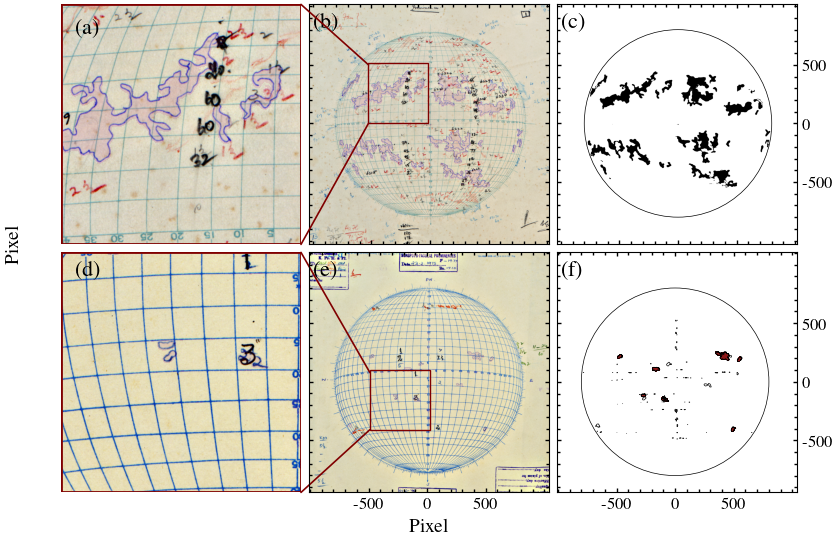

In [30]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle, Circle, ConnectionPatch
from matplotlib.colors import PowerNorm

mpl.style.use('bkj_style.mplstyle')

# Create figure
fig = plt.figure(figsize=(8,8))

# Define axes positions with more space for arrows
ax_a = fig.add_axes([0.01,0.32,0.3, 0.3])
ax_b = fig.add_axes([0.32,0.32,0.3, 0.3])
ax_c = fig.add_axes([0.63,0.32,0.3, 0.3])
ax_d = fig.add_axes([0.01,0.01,0.3, 0.3])
ax_e = fig.add_axes([0.32,0.01,0.3, 0.3])
ax_f = fig.add_axes([0.63,0.01,0.3, 0.3])

# --- Load and prepare images ---
reconstruct = cv2.imread('/home/dibya/ML_project/prediction_patch/sch_19370102_0849_kkkk_sharpen.tif', cv2.IMREAD_COLOR)
reconstruct = cv2.cvtColor(reconstruct, cv2.COLOR_BGR2RGB)
reconstruct = cv2.flip(reconstruct, 0)
reconstruct = Image.fromarray(reconstruct).resize((2048, 2048))
reconstruct = np.array(reconstruct)

# Define center and ROI for zoom (plot a)
center_x, center_y = 1032, 1032  # Center of full image
zoom_size = 512  # 512x512 zoom region

# Define ROI coordinates (-500 to 0 in x, 0 to 500 in y)
roi_x_start = center_x - 525  # -500 from center
roi_x_end = center_x-10          # 0 from center
roi_y_start = center_y        # 0 from center 
roi_y_end = center_y + 500   # +500 from center

# --- Plot (a) - Zoomed Region ---
ax_a.imshow(images_sh[9], origin='lower', alpha=1, norm=PowerNorm(gamma=1.5), rasterized=True,
           extent=[-512, 0, 0, 512])
ax_a.contourf(masks[9], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred', 
              linestyles='-', origin='lower', linewidths=0.1, rasterized=True,
              extent=[-512, 0, 0, 512])

# Set ticks for zoomed region
ax_a.set_xticks([-400, -200, 0])
ax_a.set_yticks([100, 300, 500])
ax_a.set_xticklabels(['-400', '-200', '0'])
ax_a.set_yticklabels(['100', '300', '500'])
ax_a.annotate('(a)', (-480, 450), fontsize=16)
ax_a.tick_params(axis='both', labelsize=12,labelbottom=False)
ax_a.grid()
ax_a.set_axis_off()

from matplotlib.patches import Rectangle

# Add a red rectangle around the plot edges
rect1 = Rectangle((-512, 0), width=512, height=512,
                 fill=False, edgecolor='maroon', linewidth=2, zorder=100,rasterized=True)
ax_a.add_patch(rect1)

# --- Plot (b) - Full View ---
ax_b.imshow(reconstruct, origin='lower', alpha=1, norm=PowerNorm(gamma=1.5), rasterized=True)
ax_b.contourf(reconstructed[0], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred',
             linestyles='-', origin='lower', linewidths=0.01, rasterized=True)

# Mark zoom region on full plot (red rectangle)
zoom_rect = Rectangle((roi_x_start, roi_y_start), zoom_size, zoom_size,
                     fill=False, color='maroon', linewidth=1,rasterized=True)
ax_b.add_patch(zoom_rect)

# Set ticks for full view
ax_b.set_xticks([center_x-500, center_x, center_x+500])
ax_b.set_yticks([center_y-500, center_y, center_y+500]) 
ax_b.set_xticklabels(['-500', '0', '500'])
ax_b.set_yticklabels(['-500', '0', '500'])
ax_b.annotate('(b)', (45, 1850), fontsize=16)
ax_b.tick_params(axis='both', labelsize=12,labelleft=False,labelbottom=False)
ax_b.grid()

# --- Add Connection Arrows ---
# Arrow 1: Top-left corner
con1 = ConnectionPatch(
    xyA=(roi_x_start, roi_y_end),    # Top-left of box in (b)
    xyB=(0, 512),                # Top-left of (a)
    coordsA=ax_b.transData,         # Data coordinates of (b)
    coordsB=ax_a.transData,         # Data coordinates of (a)
    axesA=ax_b, axesB=ax_a,
    arrowstyle="-",
    linewidth=1.2, 
    color="maroon",
    mutation_scale=15,rasterized=True
)

# Arrow 2: Bottom-right corner
con2 = ConnectionPatch(
    xyA=(roi_x_start, roi_y_start),   # Bottom-right of box in (b)
    xyB=(0, 0),                     # Bottom-right of (a)
    coordsA=ax_b.transData,         # Data coordinates of (b)
    coordsB=ax_a.transData,         # Data coordinates of (a)
    axesA=ax_b, axesB=ax_a,
    arrowstyle="-",
    linewidth=1.2, 
    color="maroon",
    mutation_scale=15,rasterized=True
)

fig.add_artist(con1)
fig.add_artist(con2)

# --- Plot (c) ---
#ax_c = plt.subplot2grid((2, 3), (0, 2))
ax_c.imshow(reconstructed[0], cmap='gray_r', origin='lower', alpha=1, norm=PowerNorm(gamma=1.5),rasterized=True)
circle = Circle(center1, 800, color='black', fill=False, linewidth=0.5,rasterized=True)
ax_c.add_patch(circle)
#set_relative_ticks(ax_c, *center1)
ax_c.set_xticks(xticks_pixels)
ax_c.set_yticks(yticks_pixels)
ax_c.set_xticklabels([f"{x:.0f}" for x in relative_ticks])
ax_c.set_yticklabels([f"{y:.0f}" for y in relative_ticks])
ax_c.annotate('(c)', (45, 1850), fontsize=16)
ax_c.tick_params(axis='both', labelsize=12,labelleft=False,labelright=True,labelbottom=False)
ax_c.grid()

# Define center and ROI for (d) and (e)
center_x1, center_y1 = 1008, 944  # Center of your image/circle#[1008.0][944.0][800.0]
zoom_size = 512  # Zoom region size

# ROI coordinates for (e) (adjust these values)
roi_x_start1 = center_x1 - 490
roi_x_end1 = center_x1 
roi_y_start1 = center_y1 -410
roi_y_end1 = center_y1

reconstruct1 = cv2.imread('/home/dibya/ML_project/prediction_patch1/sch_19750223_0000_xmmm_sharpen.tif', cv2.IMREAD_COLOR)
reconstruct1 = cv2.cvtColor(reconstruct1, cv2.COLOR_BGR2RGB)
reconstruct1 = cv2.flip(reconstruct1, 0)
reconstruct1 = Image.fromarray(reconstruct1).resize((2048, 2048))


# --- Plot (d) ---
#ax_d = plt.subplot2grid((2, 3), (1, 0))
#zoom_img1 = reconstruct1[roi_y_start:roi_y_end, roi_x_start:roi_x_end]
ax_d.imshow(images1_sh[5], origin='lower', alpha=1, norm=PowerNorm(gamma=1.5),rasterized=True,extent=[-512, 0, -512,0])
ax_d.contourf(masks1[5], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred', 
              linestyles='-', origin='lower', linewidths=0.1,rasterized=True,extent=[-512, 0, -512,0])
#set_relative_ticks(ax_d, *center3)
# ax_d.set_xticks([-200, -100, 0])
ax_d.set_yticks([-500, -300, -100])
# ax_d.set_xticklabels(['-200', '-100', '0'])
# ax_d.set_yticklabels(['-200', '-100', '0'])
ax_d.annotate('(d)', (-480, -50), fontsize=16)
ax_d.tick_params(axis='both', labelsize=12)
ax_d.grid()
# Turn off the axis (spines and ticks)
ax_d.set_axis_off()

from matplotlib.patches import Rectangle

# Add a red rectangle around the plot edges
rect = Rectangle((-512, -512), width=512, height=512,
                 fill=False, edgecolor='maroon', linewidth=2, zorder=100,rasterized=True)
ax_d.add_patch(rect)

# --- Plot (e) ---
#ax_e = plt.subplot2grid((2, 3), (1, 1))

ax_e.imshow(reconstruct1, origin='lower',rasterized=True, alpha=1, norm=PowerNorm(gamma=1.5))
ax_e.contourf(reconstructed1[0], levels=[0.5, 1.5], alpha=0.1, colors='mediumvioletred', 
              linestyles='-', origin='lower', linewidths=0.01,rasterized=True)
#set_relative_ticks(ax_e, *center2, label=True)
# Define center coordinates (adjust these if needed)

# Mark zoom region on (e)
zoom_rect1 = Rectangle((roi_x_start1, roi_y_start1), 
                     512, 512,  # Width and height
                     fill=False, color='maroon', linewidth=1,rasterized=True)
ax_e.add_patch(zoom_rect1)
# Function to convert absolute pixels to relative coordinates

# Set ticks in relative coordinates (-500, 0, 500)
relative_ticks1 = [-500, 0, 500]
xticks_pixels1 = [center_x1 + x for x in relative_ticks1]
yticks_pixels1 = [center_y1 + y for y in relative_ticks1]

# Use the same relative ticks for ax2
ax_e.set_xticks(xticks_pixels1)
ax_e.set_yticks(yticks_pixels1)
ax_e.set_xticklabels([f"{x:.0f}" for x in relative_ticks1])
ax_e.set_yticklabels([f"{y:.0f}" for y in relative_ticks1])
ax_e.set_xlabel('Pixel',fontsize=14)
ax_e.annotate('(e)', (45, 1850), fontsize=16)
ax_e.tick_params(axis='both', labelsize=12,labelleft=False)
ax_e.grid()

# --- Add Connection Arrows for (d)-(e) ---
# Arrow 1: Top-left corner
con3 = ConnectionPatch(
    xyA=(roi_x_start1, roi_y_end1+80),    # Top-left of box in (e)
    xyB=(0,0),                # Top-left of (d)
    coordsA=ax_e.transData,         # Data coordinates of (e)
    coordsB=ax_d.transData,         # Data coordinates of (d)
    axesA=ax_e, axesB=ax_d,
    arrowstyle="-", 
    linewidth=1.2, 
    color="maroon",
    mutation_scale=15,rasterized=True
)

# Arrow 2: Bottom-right corner
con4 = ConnectionPatch(
    xyA=(roi_x_start1, roi_y_start1),   # Bottom-right of box in (e)
    xyB=(0,-512),                  # Bottom-right of (d)
    coordsA=ax_e.transData,         # Data coordinates of (e)
    coordsB=ax_d.transData,         # Data coordinates of (d)
    axesA=ax_e, axesB=ax_d,
    arrowstyle="-",
    linewidth=1.2, 
    color="maroon",
    mutation_scale=15,rasterized=True
)

ax_e.add_artist(con3)
ax_e.add_artist(con4)

# --- Plot (f) ---
#ax_f = plt.subplot2grid((2, 3), (1, 2))
ax_f.contourf(filtered_mask, levels=[0.5, 1.5], colors='maroon', alpha=0.9, origin='lower',rasterized=True)
#ax_f.contourf(original_mask-filtered_mask, levels=[0.5, 1.5], colors='None',edgecolor='maroon', alpha=0.9, origin='lower',rasterized=True)  # Semi-transparent red overlay
ax_f.contour(original_mask - filtered_mask, 
             levels=[0.5, 1.5], 
             colors='none',
             linestyles='-',      # Solid lines (default)
             linewidths=0.5,        # Edge thickness
             edgecolor='maroon',
             alpha=0.9,
             origin='lower',
             rasterized=True)
circle1 = Circle(center2, 800, color='black', fill=False, linewidth=0.5)
ax_f.add_patch(circle1)
#ax_e.set_xticks(xticks_pixels1)
ax_f.set_xticks(xticks_pixels1)
ax_f.set_yticks(yticks_pixels1)
ax_f.set_xticklabels([f"{x:.0f}" for x in relative_ticks1])
ax_f.set_yticklabels([f"{y:.0f}" for y in relative_ticks1])
ax_f.annotate('(f)', (45, 1850), fontsize=16)
ax_f.tick_params(axis='both', labelsize=12,labelleft=False,labelright=True)
ax_f.grid()

fig.text(-0.06, 0.32, 'Pixel', va='center', rotation='vertical', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plage_prediction.pdf', dpi=200, bbox_inches='tight')
plt.show()